In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 设置支持中文的字体（Windows 通常用 SimHei，macOS 用 Arial Unicode MS）
plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows
# plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']  # macOS
# plt.rcParams['font.sans-serif'] = ['Noto Sans CJK JP']  # Linux（需安装）

# 解决负号 '-' 显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False



In [2]:
# 加载数据
df = pd.read_csv("D://archive//Breast_cancer_dataset.csv")  # 替换为你的数据路径
# 1. 删除全 NaN 的列
df = df.dropna(axis=1, how='all')
print(df.head())
print("\n数据形状:", df.shape)  # (569, 32)
print("\n缺失值检查:\n", df.isnull().sum())  # 无缺失值

# 诊断分布
print("\n诊断分布:\n", df['diagnosis'].value_counts())  # B:357, M:212

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  perimeter_worst  area_wor

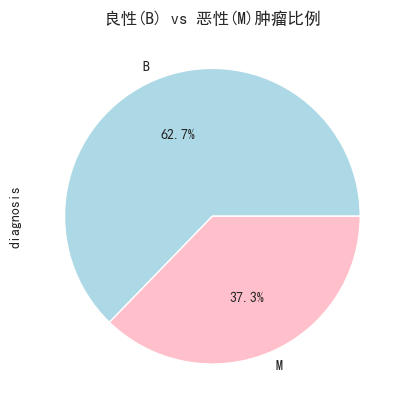

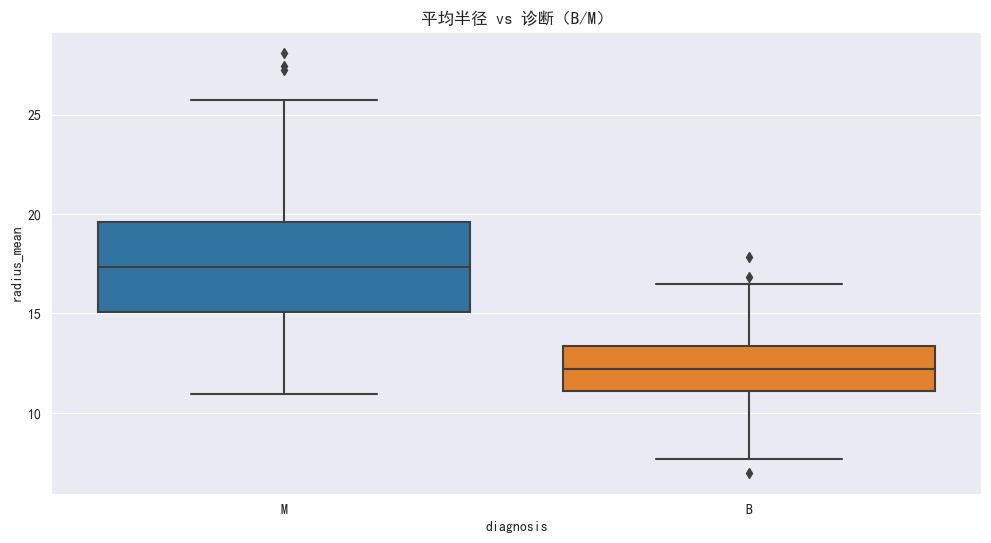

C:\Users\mechi\AppData\Local\Temp\ipykernel_16468\2011014209.py:13: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_matrix = df.corr()


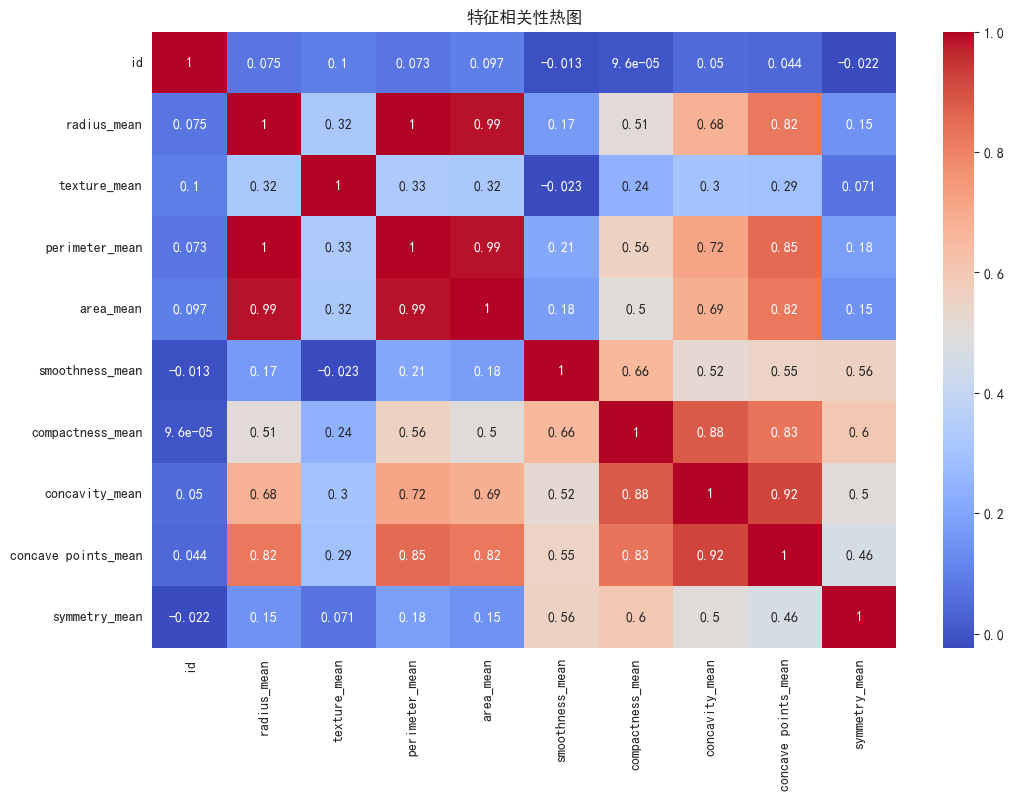

In [3]:
# 诊断类别分布（饼图）
df['diagnosis'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['lightblue', 'pink'])
plt.title("良性(B) vs 恶性(M)肿瘤比例")
plt.show()

# 关键特征分布（箱线图）
plt.figure(figsize=(12, 6))
sns.boxplot(x='diagnosis', y='radius_mean', data=df)
plt.title("平均半径 vs 诊断（B/M）")
plt.show()

# 特征相关性热图（前10个特征）
corr_matrix = df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix.iloc[:10, :10], annot=True, cmap='coolwarm')
plt.title("特征相关性热图")
plt.show()

In [5]:


# 分离特征与标签
X = df.drop(['id', 'diagnosis'], axis=1)
y = df['diagnosis'].map({'M': 1, 'B': 0})  # 转换为数值标签

# 标准化特征
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 划分训练集/测试集
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')  # 也可以用 'median' 或 'constant'
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)
print("X_train shape:", X_train.shape)
print("X_train dtype:", X_train.dtype)
import numpy as np

print("NaN in X_train:", np.isnan(X_train).any())
print("inf in X_train:", np.isinf(X_train).any())

print("NaN in X_test:", np.isnan(X_test).any())
print("inf in X_test:", np.isinf(X_test).any())
print("Columns with zero variance:", np.where(np.var(X_train, axis=0) == 0)[0])
print("X_train dtype:", X_train.dtype)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (455, 30)
X_train dtype: float64
NaN in X_train: False
inf in X_train: False
NaN in X_test: False
inf in X_test: False
Columns with zero variance: []
X_train dtype: float64
X_train shape: (455, 30)
X_test shape: (114, 30)


              precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

AUC Score: 0.995250573206682


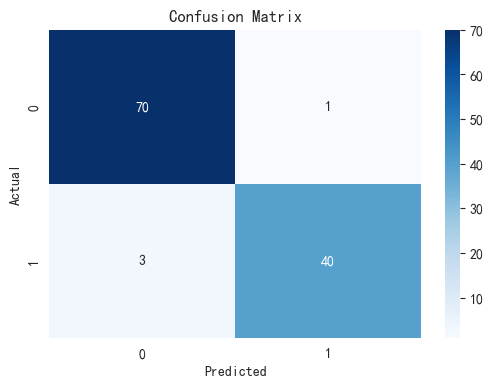

In [11]:
from sklearn.metrics import roc_auc_score

# 随机森林分类器
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

from joblib import dump

# 保存模型和标准化器（保持数据预处理一致性）
dump(rf, 'C://Users//mechi//PycharmProjects//乳腺癌诊断预测与特征分析//breast_cancer_rf_model.joblib')  # 保存模型
dump(scaler, 'C://Users//mechi//PycharmProjects//乳腺癌诊断预测与特征分析//breast_cancer_scaler.joblib')  # 保存标准化器

# 评估指标
print(classification_report(y_test, y_pred))
print("AUC Score:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))



# 混淆矩阵可视化
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

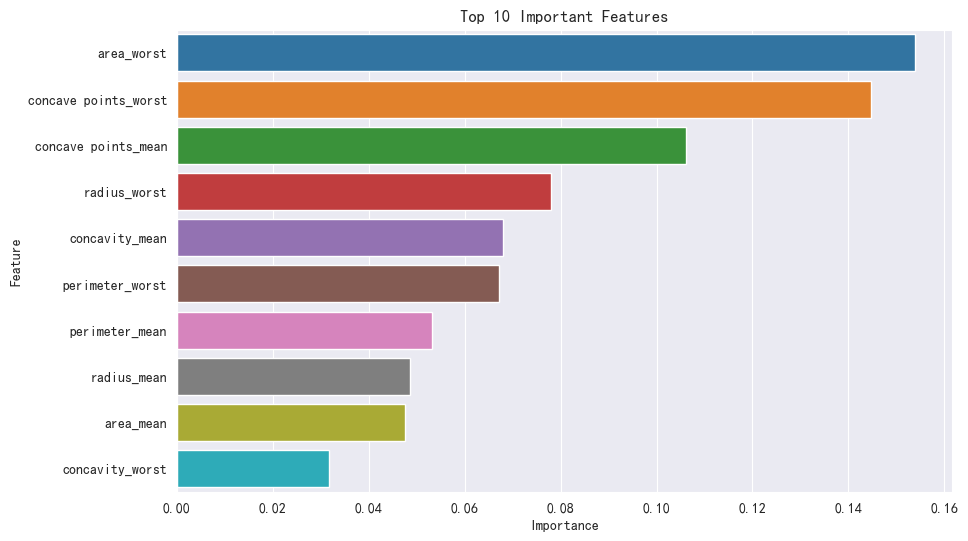

In [7]:
# 获取特征重要性
importances = rf.feature_importances_
features = X.columns

# 可视化Top 10特征
top_features = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values('Importance', ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=top_features)
plt.title('Top 10 Important Features')
plt.show()

In [17]:
from sklearn.model_selection import GridSearchCV
param_grid = {'n_estimators': [50,100,200], 'max_depth': [None,10,20]}
grid_search = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)
grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': 10, 'n_estimators': 50}


In [20]:
from flask import jsonify, request, Flask

app = Flask(__name__)

@app.route('/predict', methods=['POST'])
def predict():
    data = request.json
    features = [[data[f] for f in X.columns]]  # 假设前端传入格式化数据
    scaled_features = scaler.transform(features)
    prediction = rf.predict_proba(scaled_features)[0][1]
    return jsonify({'malignant_probability': float(prediction)})

if __name__ == '__main__':
    app.run(debug=True)

 * Serving Flask app '__main__'
 * Debug mode: on


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
 * Restarting with watchdog (windowsapi)


SystemExit: 1

In [3]:
from flask import jsonify, request, Flask
import pandas as pd
import joblib

app = Flask(__name__)

# 加载模型和预处理对象（实际路径替换为你的文件）
X = pd.DataFrame(columns=["feature1", "feature2", "feature3"])  # 示例特征列名
scaler = joblib.load("C://Users//mechi//PycharmProjects//乳腺癌诊断预测与特征分析//breast_cancer_scaler.joblib")  # 替换为你的预处理文件
rf = joblib.load("C://Users//mechi//PycharmProjects//乳腺癌诊断预测与特征分析//breast_cancer_rf_model.joblib")  # 替换为你的模型文件

@app.route('/predict', methods=['POST'])
def predict():
    try:
        data = request.json
        features = [[data[f] for f in X.columns]]
        scaled_features = scaler.transform(features)
        prediction = rf.predict_proba(scaled_features)[0][1]
        return jsonify({'malignant_probability': float(prediction)})
    except Exception as e:
        return jsonify({"error": str(e)}), 400

if __name__ == '__main__':
    app.run(debug=True)

 * Serving Flask app '__main__'
 * Debug mode: on


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
 * Restarting with watchdog (windowsapi)


SystemExit: 1

C:\Users\mechi\anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3468: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)
